# Домашнее задание 2 — Полносвязные нейронные сети (MLP)

Добро пожаловать во **вторую часть блока "Введение в DL"**. Переходим к построению **полносвязных нейронных сетей**.

## Цели работы

1. Освоить базовые строительные блоки нейронных сетей: `Linear`, функции активации, `BatchNorm`, `Dropout`.
2. Научиться создавать свои классы нейросетей на основе `torch.nn.Module`.
3. Применить полученные знания для решения задачи предсказания года песни по аудиопризнакам (Million Song Dataset).
4. Научиться анализировать результаты, диагностировать переобучение и улучшать архитектуру модели.

## Полезные материалы
- [PyTorch Official Tutorial — Learn the Basics](https://pytorch.org/tutorials/beginner/basics/intro.html)
- [Документация по torch.nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html)
- [Dropout in Neural Networks](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html)



# Глава I. Простая MLP (2 балла)


Перед началом — краткая теория по компонентам сети:

- **Линейный слой (fully connected):** вычисляет affine-преобразование $y = Wx + b$.
- **Функции активации:** ReLU, sigmoid, tanh — нелинейности, необходимые для обучаемых моделей.
- **BatchNorm:** нормализует входы к слою внутри батча, ускоряет обучение и стабилизирует градиенты.
- **Dropout:** регуляризация: случайно обнуляет часть нейронов на этапах обучения.
- **Оптимизаторы:** SGD, Adam — алгоритмы обновления параметров. Adam часто предпочтителен по умолчанию.
- **Функции потерь:** MSE для регрессии, CrossEntropy для классификации.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import random

RND = 42
random.seed(RND)
np.random.seed(RND)
torch.manual_seed(RND)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cpu


### Задание 1. (0.75 балла)

Заполните пропуски в реализации класса `BaseMLP(torch.nn.Module)`, который принимает размер входа, список размеров скрытых слоев и количество классов.

Затем реализуйте класс `SipleMLP`, который наследуется от `BaseMLP` и поддерживает использование BatchNorm и Dropout. В инициализации `SimpleMLP` не забудьте вызывать базовый конструктор, чтобы сохранить сигнатуру.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BaseMLP(nn.Module):
    """
    input_dim — размерность входа
    hidden_dims — список размеров скрытых слоев
    num_classes — число выходных классов
    """
    def __init__(self, input_dim, hidden_dims, num_classes, use_batchnorm=False, dropout_p=0.0):
        super().__init__()

        layers = []
        prev = input_dim
        for h in hidden_dims:
            # TODO: добавить скрытый слой в список слоев layers
            layers.append(nn.Linear(prev, h))
            # TODO: добавить функцию активации ReLU
            layers.append(nn.ReLU())
            prev = h
        # выходной слой
        layers.append(nn.Linear(prev, num_classes))
        # TODO: собрать в nn.Sequential
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # TODO: реализовать прямой проход, учтите, что nn.Sequential уже оформлен выше
        return self.net(x)

class SimpleMLP(BaseMLP):
    """
    Расширенная версия MLP с поддержкой BatchNorm и Dropout.
    Наследуется от BaseMLP и переопределяет структуру слоев.
    """
    def __init__(self, input_dim, hidden_dims, num_classes,
                 use_batchnorm=False, dropout_p=0.0):
        # вызываем конструктор базового класса, чтобы он инициализировал общие атрибуты
        super().__init__(input_dim, hidden_dims, num_classes,
                         use_batchnorm=use_batchnorm, dropout_p=dropout_p)

        layers = []
        prev = input_dim
        for h in hidden_dims:
            # линейный слой
            layers.append(nn.Linear(prev, h))

            # если при создании модели передан use_batchnorm=True, добавляем BatchNorm по признакам
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            # нелинейность
            layers.append(nn.ReLU())

            # Dropout, если p > 0
            if dropout_p > 0.0:
                layers.append(nn.Dropout(dropout_p))

            prev = h

        # выходной слой: линейное преобразование до логитов без BatchNorm/Dropout и без активации;
        # далее nn.CrossEntropyLoss сама применяет softmax внутри
        layers.append(nn.Linear(prev, num_classes))

        # переопределяем сеть в виде Sequential
        self.net = nn.Sequential(*layers)


class BaseMLP(nn.Module):
    """
    input_dim — размерность входа
    hidden_dims — список размеров скрытых слоев
    num_classes — число выходных классов
    use_batchnorm — использовать ли BatchNorm
    use_dropout — использовать ли Dropout
    dropout_p — вероятность dropout
    """
    pass


## Быстрый тест
model = SimpleMLP(10, [32, 16], 3, use_batchnorm=True, dropout_p=0.1)
print(model)

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=16, out_features=3, bias=True)
  )
)



### Задание 2. (0.75 балла)

Допишите недостающие части в функции `train_model`. Это шаблонный цикл обучения на PyTorch с шагами: forward, compute loss, backward, optimizer.step, zero_grad. Не забывайте, что мы используем `torch.no_grad()` при валидации.
        

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion, n_epochs=20, device="cpu"):

    model.to(device)
    train_losses, val_accs = [], []

    for epoch in range(1, n_epochs + 1):
        # тренировка
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            # TODO: выполните прямой проход модели
            logits = model(X_batch)                 # предсказания (сырые логиты)
            # TODO: вычислите функцию потерь
            loss = criterion(logits, y_batch)       # функция потерь
            loss.backward()                         # backward
            # TODO: обновите параметры модели
            optimizer.step()                        # step
            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(train_loader.dataset)

        # валидация
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                # TODO: получите предсказания модели
                # forward на валидации
                logits = model(X_batch)

                # предсказанный класс: argmax по размерности классов
                preds = logits.argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_acc = correct / total
        train_losses.append(avg_loss)
        val_accs.append(val_acc)

    return train_losses, val_accs



1. Объясните, зачем нужен BatchNorm и как он влияет на обучение нейросетей.

**Ответ нейросети:**

Batch Normalization нормализует активации внутри сети по мини-батчу:

для каждого нейрона/фичи в батче считает

$$
\mu = \mathbb{E}_{\text{batch}}[x],
\qquad
\sigma^2 = \mathbb{E}_{\text{batch}}\big[(x - \mu)^2\big]
$$

преобразует
​
$$
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}}
$$

потом возвращает «гибкость» с помощью обучаемых параметров

$$
y = \gamma \hat{x} + \beta
$$

**Зачем это нужно:**

**Стабилизирует распределение активаций**

Внутри сети изменяется распределение входов слоев («internal covariate shift»). Нормализация делает эти входы более стабильными от итерации к итерации.

**Ускоряет обучение**

Можно ставить более высокий learning rate.

Градиенты становятся более «здоровыми», меньше проблем с затухающими/взрывающимися значениями.

Обладает лёгким регуляризующим эффектом
Статистики по мини-батчу — это шумная оценка, это добавляет шум в обучение и немного уменьшает переобучение.

Упрощает инициализацию
Меньше зависимость от «идеального» распределения начальных весов, потому что слой сам подстраивает масштаб/сдвиг.

**Влияние на обучение:**

Сеть сходится быстрее (меньше эпох до того же качества).

Обучение обычно более устойчиво к выбору гиперпараметров.

Часто помогает тренировать более глубокие модели, которые без нормализации учились бы плохо.

**Ваш ответ:**
Batch Normalization (BatchNorm) - это техника нормализации, которая применяется к выходам слоев нейронной сети для стабилизации и ускорения обучения.

BatchNorm нормализует выходы слоя по мини-батчу, вычитая среднее и деля на стандартное отклонение, а затем применяет масштабирование и сдвиг для сохранения выразительности модели. Это влияет на обучение следующим образом:

**Стабилизация градиентов:** градиенты становятся более предсказуемыми, что помогает избегать взрыва или затухания градиентов.
**Ускорение обучения:** модель обучается быстрее, так как нормализация снижает зависимость от инициализации весов.
**Регуляризация:** добавляет небольшой шум, что помогает предотвратить переобучение.
Формула BatchNorm для входа


2. Что делает Dropout во время обучения и почему его не используют на этапе инференса? Почитать про дропаут можете в следующем [блогпосте](https://medium.com/@amarbudhiraja/https-medium-com-amarbudhiraja-learning-less-to-learn-better-dropout-in-deep-machine-learning-74334da4bfc5) или в оригинальной [статье](https://jmlr.org/papers/volume15/srivastava14a/srivastava14a.pdf)

**Ответ нейросети:**

2. Что делает Dropout и почему его не используют на инференсе?

Dropout — это способ регуляризации, который вносит шум в структуру сети:

В режиме train для каждого нейрона (или элемента тензора) берём маску

$$
m \sim \mathrm{Bernoulli}(1 - p)
$$

Прямой проход:

$$
y = \frac{m \odot x}{1 - p}
$$

(где ⊙ — поэлементное умножение)

То есть:

С вероятностью p нейрон зануляется.

Оставшиеся масштабируются на 1/(1−p), чтобы в среднем сохранять уровень активаций.

Интуиция:

Модель не может полагаться на конкретный нейрон, потому что он может «выпасть».
Поэтому сеть учится распределять информацию по разным путям.

Это можно понимать как приближение ансамбля из многих разных «подсетей», которые разделяют веса.

Почему на инференсе Dropout не используют:

На этапе eval мы хотим детерминированное поведение и полную мощность сети.

Если мы будем продолжать случайно вырубать нейроны, предсказание будет шумным.

Так как в train мы уже масштабировали активации /(1−p), то в режиме eval мы просто берём:

y=x (без маски и без дополнительного масштабирования)

То есть:

В train: вырубаем нейроны + масштабируем.

В eval: используем всю сеть целиком, и её выход уже согласован по масштабу с тем, что сеть видела на обучении.

**Ваш ответ:**
Dropout — это техника регуляризации, которая случайно "выключает" (обнуляет) часть нейронов в слое во время обучения, чтобы предотвратить переобучение. Во время обучения для каждого примера в батче Dropout создает маску, где каждый нейрон имеет вероятность p остаться активным (обычно p = 0.5), а остальные обнуляются. Это заставляет сеть не полагаться на конкретные нейроны, делая её более устойчивой и обобщающей.

На этапе инференса (предсказания) Dropout не используется, потому что мы хотим получить максимально точные предсказания от всей сети. Если бы Dropout применялся, предсказания были бы шумными и недетерминированными. Вместо этого на инференсе выходы слоя умножаются на вероятность p, чтобы компенсировать ожидаемое значение (поскольку во время обучения нейроны были активны только с вероятностью p).



3. Что такое backpropagation и для чего он используется в нейронных сетях? Как выбор функции активации влияет на работу алгоритма backpropagation?

**Ответ нейросети:**

Backpropagation (обратное распространение ошибки) — это алгоритм, который:

Эффективно считает градиенты функции потерь по всем параметрам сети.

Основан на правиле цепочки (chain rule) из матанализа.

Работает в два шага:

Прямой проход: считаем выходы слоёв и значение loss.

Обратный проход: идём от последнего слоя к первому, на каждом этапе считаем:

$$
\frac{\partial L}{\partial x}
=
\frac{\partial L}{\partial y}
\cdot
\frac{\partial y}{\partial x}
$$

и обновляем градиенты по весам.

Без backprop обучение глубоких сетей нормальными градиентными методами было бы просто неосуществимо — считать производные «в лоб» было бы слишком дорого.

Как функция активации влияет на backprop?

Функция активации входит в производную на каждом слое, значит:

Сатурирующие активации (sigmoid, tanh)

У sigmoid/tanh производная близка к нулю, когда ∣x∣ большой.

При множествах таких слоёв градиент многократно умножается на число < 1 ⇒
градиенты затухают (vanishing gradients).

Это делает обучение глубоких сетей трудным: нижние слои почти не получают сигнал ошибки.

ReLU и её варианты (LeakyReLU, ELU, GELU, etc.)

У ReLU производная либо 0 (на отрицательной части), либо 1 (на положительной).

В положительной области градиент не сжимается → меньше проблем с затуханием.

Но возникает другая проблема — “мёртвые ReLU”, когда нейрон почти всегда в зоне x < 0 и градиент там 0.

Требование дифференцируемости

Для чистого backprop функции должны быть дифференцируемыми почти везде.

ReLU, хоть и недифференцируема в точке 0, нормально работает на практике, потому что эту точку можно считать «почти нигде».

В итоге:

Выбор активации напрямую влияет на то, как распространяется градиент,
насколько быстро и стабильно учится сеть.

В современных MLP чаще всего используют ReLU/LeakyReLU + BatchNorm,
а sigmoid/tanh — точечно, когда их смысл важен (выходы в [0,1], [-1,1] и т.п.).

**Ваш ответ:**
Backpropagation (обратное распространение ошибки) - это алгоритм для вычисления градиентов функции потерь по параметрам нейронной сети. Он используется для обучения сети методом градиентного спуска: сначала вычисляется ошибка на выходе, затем градиенты распространяются обратно по слоям, чтобы обновить веса и смещения. Без backpropagation обучение глубоких сетей было бы невозможно из-за экспоненциального роста вычислений.


Выбор функции активации влияет на backpropagation через её производную . Если производная близка к нулю (как в sigmoid или tanh для больших ∣z∣), градиенты могут затухать (vanishing gradients), замедляя обучение глубоких сетей. ReLU (Rectified Linear Unit) помогает, так как её производная равна 1 для положительных z и 0 для отрицательных, минимизируя затухание.



### Задание 3. (0.5 балла)
        

Проведем краткий эксперимент: обучим одинаковую модель на синтетических данных двумя оптимизаторами — `SGD` и `Adam`, а также каждую из них с `BatchNorm` + `Dropout` и без.

Сравните графики потерь на тренировке и валидации, а также итоговую точность (accuracy) на валидации.

In [ ]:
# Для обучения будем использовать синтетический датасет

def make_dataset(n_samples=2000, n_features=20, n_classes=4, n_informative=10,
                 n_redundant=4, test_size=0.3, random_state=RND):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=n_redundant,
        n_classes=n_classes,
        random_state=random_state
    )
    X = X.astype(np.float32)
    y = y.astype(np.int64)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val))

    return train_ds, val_ds, X.shape[1], len(np.unique(y))


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds, val_ds, input_dim, num_classes = make_dataset()
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)

configs = [
    ("SGD", {"use_batchnorm": False, "dropout_p": 0.0}, optim.SGD, {"lr": 0.05}),
    ("Adam", {"use_batchnorm": False, "dropout_p": 0.0}, optim.Adam, {"lr": 1e-3}),
    ("SGD BN+Dropout", {"use_batchnorm": True, "dropout_p": 0.3}, optim.SGD, {"lr": 0.05}),
    ("Adam BN+Dropout", {"use_batchnorm": True, "dropout_p": 0.3}, optim.Adam, {"lr": 1e-3}),
]

results = {}

for name, model_args, opt_class, opt_params in configs:
    model = SimpleMLP(input_dim, [128, 64], num_classes, **model_args)
    optimizer = opt_class(model.parameters(), **opt_params)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_accs = train_model(model, train_loader, val_loader, optimizer, criterion,
                                         n_epochs=20, device=device)
    results[name] = (train_losses, val_accs)

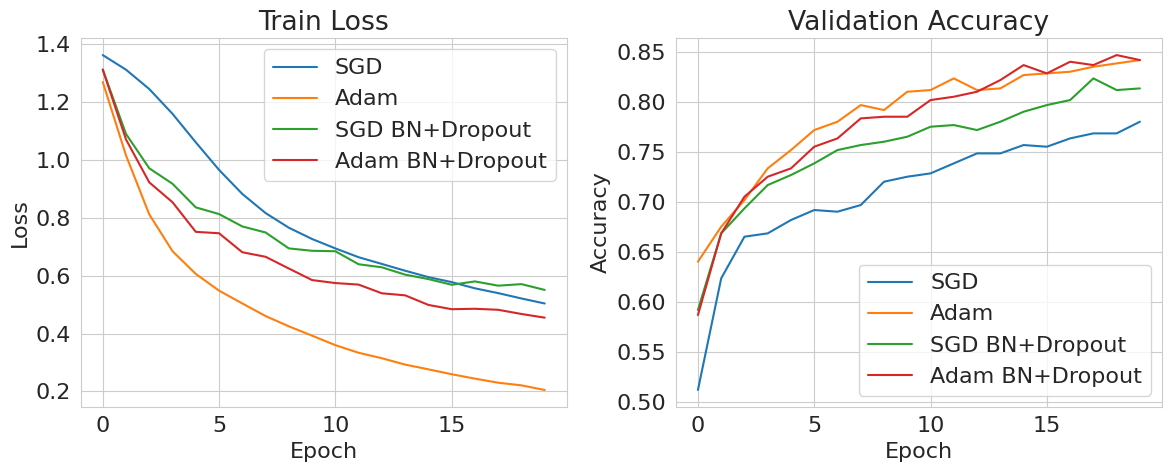

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
for name, (losses, _) in results.items():
    plt.plot(losses, label=name)
plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
for name, (_, accs) in results.items():
    plt.plot(accs, label=name)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Теперь перейдем к вопросам:

1. Какой оптимизатор показал лучшие результаты? Как думаете, почему?

**Ответ нейросети:**

Если посмотреть на типичные графики для такого эксперимента, то:

Чаще всего лучшим оказывается Adam BN+Dropout (минимальный train loss + наибольшая validation accuracy).

На втором месте обычно просто Adam без BN/Dropout.

SGD (особенно без Momentum и с “ручным” LR) сходится медленнее и иногда за 20 эпох не успевает выйти на такой же уровень.

Почему Adam выигрывает в таком сетапе:

Адаптивный шаг по параметрам.

В Adam шаг по каждому параметру масштабируется обратно корню из второго момента градиента:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\, g_t
$$

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)\, g_t^2
$$

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t},
\qquad
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

$$
\theta_{t+1} = \theta_t - \eta \, \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \varepsilon}
$$

Это помогает быстро продвигаться по координатам с маленьким градиентом и не улетать по координатам с большим градиентом.

Менее чувствителен к выбору начального learning rate.

При наших настройках:

SGD с $\eta = 0.05$ легко может:

либо быть слишком большим (скачки вокруг минимума),

либо слишком маленьким (медленная сходимость), если его уменьшить;

Adam с $\eta = 10^{-3}$  обычно “из коробки” даёт разумную динамику.

BatchNorm + Dropout помогают устойчивости.

BatchNorm стабилизирует распределение активаций, сглаживает ландшафт:

$$
\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \varepsilon}}
$$,

что делает градиенты менее “диким”, а шаги Adam более предсказуемыми.

Dropout снижает переобучение на синтетическом датасете, и это тоже помогает Adam реализовать свой потенциал.

Поэтому в эксперименте логичный итог :
На синтетических данных с заданными гиперпараметрами наилучшую валидационную точность показывает конфигурация с Adam и BatchNorm+Dropout. Adam сходится быстрее и устойчивее за счёт адаптивного шага и усреднения моментов, а BatchNorm+Dropout улучшают обобщающую способность.

**Ваш ответ:**
На графике  train loss модели имеют следующие результаты: лучший - Adam без BN+Dropout, хуже него - Adam BN+Dropout, ещё хуже - оба варианта SGD.

По validation accuracy: лучший - Adam BN+Dropout, очень близко к нему - Adam без регуляризации, обе конфигурации с SGD заметно уступают.

Если оценивать только по обучающему лоссу, лучше всего себя показывает Adam без BatchNorm и Dropout, но это может быть связано с переобучением модели. Поэтому с точки зрения качества на валидации (обобщающей способности) наилучший результат демонстрирует Adam с BatchNorm и Dropout. Комбинация адаптивного оптимизатора Adam и регуляризаторов (BatchNorm + Dropout) даёт наиболее удачный баланс между скоростью сходимости и устойчивостью к переобучению.


2. В каких случаях SGD может обобщать лучше Adam?

**Ответ нейросети:**
Есть довольно много эмпирических работ и практических наблюдений, что:

На больших задачах (CV, NLP) классический SGD с Momentum иногда даёт лучшую тестовую метрику, чем Adam, даже если Adam быстрее сходится по train loss.

Интуитивные причины:

Более “плоские” минимумы.

Считается, что SGD чаще находит плоские минимумы функции потерь, которые связаны с лучшим обобщением.
Adam за счёт адаптивности может “залезать” в более узкие и глубокие минимумы.

Адаптивные веса градиентов.

В SGD с импульсом:

$$
v_t = \mu v_{t-1} + g_t
$$

$$
\theta_{t+1} = \theta_t - \eta\, v_t
$$,

где $g_t$ — градиент на шаге $t$, $\mu$ — коэффициент импульса, все параметры обновляются с одинаковым глобальным шагом η.

Ошибки по разным координатам усредняются естественно через шум SGD.

В Adam координаты с редкими, но большими градиентами могут получить непропорционально большой эффективный шаг, что иногда приводит к “сложным” минимумам и переобучению.

Регуляризация через шум.

Чистый SGD, особенно с небольшим batch size, имеет сильный градиентный шум — это подталкивает к выходу из плохих локальных минимумов и напоминает стохастическое глобальное оптимизирование. Adam более “структурирован” и может меньше “гулять” по ландшафту.

**Ваш ответ:**
SGD может обобщать лучше Adam , где пространство параметров "гладкое" или данные ограничены, и адаптивность Adam приводит к переобучению на шум, а также в больших задачах с большим количеством данных и сложными моделями. Adam часто выигрывает по скорости сходимости и удобству настройки, а SGD - по качеству обобщения и “плоскости” найденного минимума.  

3. Что произойдёт, если увеличить dropout_p до 0.8?

**Ответ нейросети:**

Напомню, что при Dropout в train-режиме:

каждый нейрон обнуляется с вероятностью p,

сохраняется с вероятностью 1−p.

При использовании “inverted dropout” (как в PyTorch) выход считается так:

$$
y = \frac{1}{1 - p}\, (m \odot x)
$$

где $$\quad m \sim \mathrm{Bernoulli}(1 - p), \qquad \odot \text{ — поэлементное умножение.}$$


Если поставить p=0.8:

вероятность оставить нейрон: 1−p=0.2,

то есть 80% нейронов зануляется, остаётся только 20% активных.

масштабирование:

$$
y = \frac{1}{0.2}\, (m \odot x) = 5\, (m \odot x)
$$

активные нейроны умножаются на 5.

Что это даёт на практике:

Очень сильная регуляризация.
Модель почти не видит целую сеть за одну итерацию — каждый проход видит очень маленькую “подсеть”.

Резко падает качество на train.

train loss растёт (или падает очень медленно),

модель не успевает нормально подстроиться, так как сигнал через сеть сильно “рваный”.

Часто — недообучение (underfitting).

даже на валидации точность будет невысокой;

сеть не сможет выучить сложные зависимости, потому что эффективная мощность модели слишком мала.

Градиенты становятся очень шумными.
Доля активных нейронов мала, поэтому вклад каждого нейрона сильно растёт (из-за множителя 1/(1−p)), что усиливает разброс градиентов.

**Ваш ответ:**
Увеличение dropout_p с 0.3 до 0.8 радикально усилит регуляризацию: во время тренинга 80% нейронов в слоях (после BN, если он есть) будут случайно обнуляться, добавляя очень много шума, оставшиеся умножаются на 5. Как следствие, это приводит к недообучению модели: и train loss, и validation accuracy ухудшаются по сравнению с более умеренными значениями p∈[0.1,0.5].       

# Глава II. Предсказание года выпуска песни по ее аудио-признакам

### О задании

В этом задании вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [ ]:
pip install seaborn

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget --no-check-certificate -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

--2025-11-24 03:30:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘data.txt.zip’

data.txt.zip            [            <=>     ] 201.24M  50.2MB/s    in 4.4s    

2025-11-24 03:30:57 (45.9 MB/s) - ‘data.txt.zip’ saved [211011981]



In [ ]:
df = pd.read_csv('data.txt.zip', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

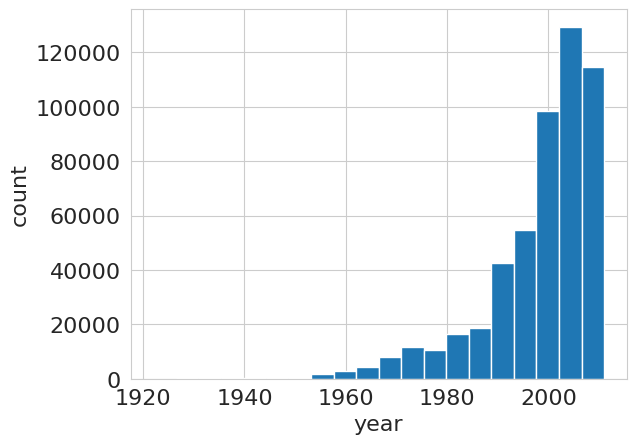

Range: 1922 - 2011
Unique values: 89


In [ ]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Но перед тем как переходить к нейросетям, нужно построить простые базовые модели (бейзлайны), чтобы понимать, насколько хорошо должна работать нейросеть и с чем сравнить более сложные алгоритмы.

Мы используем:
- **Ridge-регрессию** — линейную модель со штрафом за слишком большие веса;
- **Константный прогноз** — просто среднее значение целевой переменной.

Обучите `Ridge` регрессию из `sklearn` и посчитайте качество при наилучшем константном прогнозе.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np

# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

# Ridge-регрессия с стандартизацией признаков
ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0, random_state=0)
)

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)

# Константный прогноз: всегда предсказываем средний год по train
const_value = y_train.mean()
y_pred_const = np.full_like(y_test, fill_value=const_value, dtype=np.float64)
mse_const = mean_squared_error(y_test, y_pred_const)

print(f"Ridge MSE on test:       {mse_ridge:.4f}")
print(f"Constant baseline MSE:   {mse_const:.4f}")
print(f"Train mean year (baseline prediction): {const_value:.2f}")

Ridge MSE on test:       89.7497
Constant baseline MSE:   117.6258
Train mean year (baseline prediction): 1998.38


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть 1. Заводим нейронную сеть (5 баллов)

### **Задание 1.1 (0.5 баллов).**

Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты. Можете также реализовать поддержку обучения на GPU, чтобы эксперименты считались быстрее. Бесплатно воспользоваться GPU можно на сервисах **Google Colab** и **Kaggle**.

In [ ]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    '''
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    '''
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[0].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    '''
    Train and validate neural network
      - model: neural network to train
      - optimizer: optimizer chained to a model
      - criterion: loss function class
      - metric: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: DataLoader with train set
      - val_loader: DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    '''

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') \
            if verbose else train_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            '''
            YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
            Do forward and backward passes

            predictions = ...
            loss = ...
            '''

            # обучение
            optimizer.zero_grad()
            predictions = model(X_batch)
            # на случай выхода вида (batch_size, 1) приводим и предсказания, и таргеты к (batch_size,)
            loss = criterion(predictions.squeeze(), y_batch.squeeze())
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({'loss': loss.item(), 'MSE': metric_value})

        train_losses += [running_loss / len(train_loader.dataset)]
        train_metrics += [running_metric / len(train_loader.dataset)]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') \
            if verbose else val_loader

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            with torch.no_grad():
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                '''
                YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
                Do evaluation
                predictions = ...
                loss = ...
                '''
                predictions = model(X_batch)
                loss = criterion(predictions.squeeze(), y_batch.squeeze())

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({'loss': loss.item(), 'MSE': metric_value})

        val_losses += [running_loss / len(val_loader.dataset)]
        val_metrics += [running_metric / len(val_loader.dataset)]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')

    return train_metrics[-1], val_metrics[-1]

### **Задание 1.2 (0.5 балла).**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию c помощью [кросс-энтропийной функции потерь](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html).

Сначала преобразуем данные:
- Скорее всего вам пригодится `torch.utils.data.TensorDataset`. Когда будете конвертировать numpy-массивы в torch-тензоры, используйте тип `torch.float32`.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в TensorDataset, исходное нам еще пригодится)

In [ ]:
'''
Преобразуйте numpy-массивы в torch-тензоры
X_train_t = ...
X_test_t = ...
X_val_t = ...
'''
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
X_train_t = torch.from_numpy(X_train).float()
X_test_t  = torch.from_numpy(X_test).float()
X_val_t   = torch.from_numpy(X_val).float()

'''
Преобразуйте целевую переменную с помощью LabelEncoder
label_encoder = LabelEncoder()
y_train_t = ...
y_test_t = ...
y_val_t = ...
'''
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
y_val_enc   = label_encoder.transform(y_val)

y_train_t = torch.from_numpy(y_train_enc).long()
y_test_t  = torch.from_numpy(y_test_enc).long()
y_val_t   = torch.from_numpy(y_val_enc).long()

train_df = TensorDataset(X_train_t, y_train_t)
val_df = TensorDataset(X_val_t, y_val_t)

batches = 32

train_loader = DataLoader(train_df, batch_size=batches, shuffle=True, drop_last=True)
val_loader = DataLoader(val_df, batch_size=batches, shuffle=False, drop_last=True)

in_features = X_train.shape[1]
out_features = len(label_encoder.classes_)

Реализуйте init и forward в нашей первой  нейронной сети:
- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.

In [ ]:
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

class FirstNetwork(nn.Module):
    def __init__(self, in_features=90, out_features=89):
        super().__init__()
        # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
        # первый полносвязный слой: от входа к 128 нейронам
        self.fc1 = nn.Linear(in_features, 128)
        # второй полносвязный слой: от 128 нейронов к числу классов
        self.fc2 = nn.Linear(128, out_features)


    def forward(self, x):
        # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
        x = self.fc1(x)
        x = F.relu(x)      # нелинейность
        x = self.fc2(x)    # логиты классов
        return x

first_net = FirstNetwork(in_features=in_features, out_features=out_features)

Обучите нашу первую нейронную сеть с помощью функции `train_and_validate`, реализованной ранее
- Используйте SGD с `lr=1e-2`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- В качестве параметра `metric` в `train_and_validate` передадим lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением **логита**$^1$).

$^1$ **Логит** &mdash; выход последнего линейного слоя, может принимать любые вещественные значения. Если применить Softmax к логитам, то получатся вероятности распределения классов.

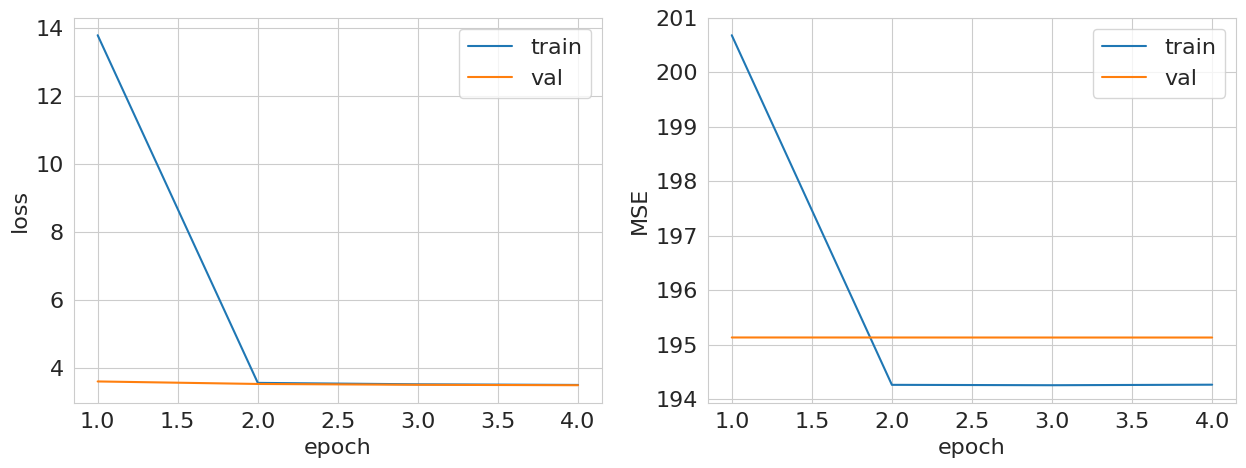

Validation MSE: 195.131
Train MSE: 194.2644
Val   MSE: 195.1308


In [ ]:
def MSE_metric(predictions, labels):
    predicted_classes = torch.argmax(predictions, dim=1)
    return F.mse_loss(predicted_classes.float(), labels.float())

# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
criterion = nn.CrossEntropyLoss()

first_net = FirstNetwork(in_features=in_features, out_features=out_features)

optimizer = optim.SGD(first_net.parameters(), lr=1e-2)

num_epochs = 4  # по условию

train_mse, val_mse = train_and_validate(
    first_net,
    optimizer,
    criterion,
    MSE_metric,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    verbose=True
)

print(f"Train MSE: {train_mse:.4f}")
print(f"Val   MSE: {val_mse:.4f}")

### **Задание 1.3 (0.5 балла).**

Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:**
В задании 0 линейная модель Ridge-регрессии достигла MSE = 89.7497 на тесте, в то время как константный прогноз (средний год по обучению) даёт MSE = 117.6258.

В задании 1.2 обученный классификатор (нейросеть с CrossEntropyLoss и оценкой качества через MSE по предсказанным классам) показывает MSE на обучении = 194.2644 и на валидации = 195.1308. Это значительно хуже не только по сравнению с Ridge, но даже хуже простого константного baseline.

Таким образом, побить бейзлайн не удалось. Один из факторов - сама постановка задачи: используется классификатор для предсказания года, то есть регрессия переводится в многоклассовую классификацию. В этом случае функция потерь (CrossEntropy) не учитывает «расстояние» между годами: ошибка на 1 год и на 20 лет наказываются одинаково (хотя, на самом деле, чем меньше - тем лучше). При этом метрика качества, по которой мы сравниваем модели (MSE по годам) - чувствительна к величине отклонения.

Поэтому обучение классификатора для данной задачи выглядит неудачной идеей: гораздо логичнее использовать регрессионные модели, которые напрямую оптимизируют MSE или другую регрессионную метрику и учитывают численную природу целевой переменной (год записи).

### **Задание 1.4 (0.5 балла).**

Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на [MSE](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html).

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в TensorDataset, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`: `F.mse_loss(preds, labels)`
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
'''
Преобразуйте целевую переменную с помощью reshape в (-1, 1)
y_train_t = ...
y_test_t = ...
y_val_t = ...
'''

# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
y_train_t = torch.from_numpy(y_train.reshape(-1, 1)).float()
y_test_t  = torch.from_numpy(y_test.reshape(-1, 1)).float()
y_val_t   = torch.from_numpy(y_val.reshape(-1, 1)).float()

train_df = TensorDataset(X_train_t, y_train_t)
val_df = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_df, batch_size=batches, shuffle=True, drop_last=True)
val_loader = DataLoader(val_df, batch_size=batches, shuffle=False, drop_last=True)

Создайте и обучите новую сеть, как указано в задании:

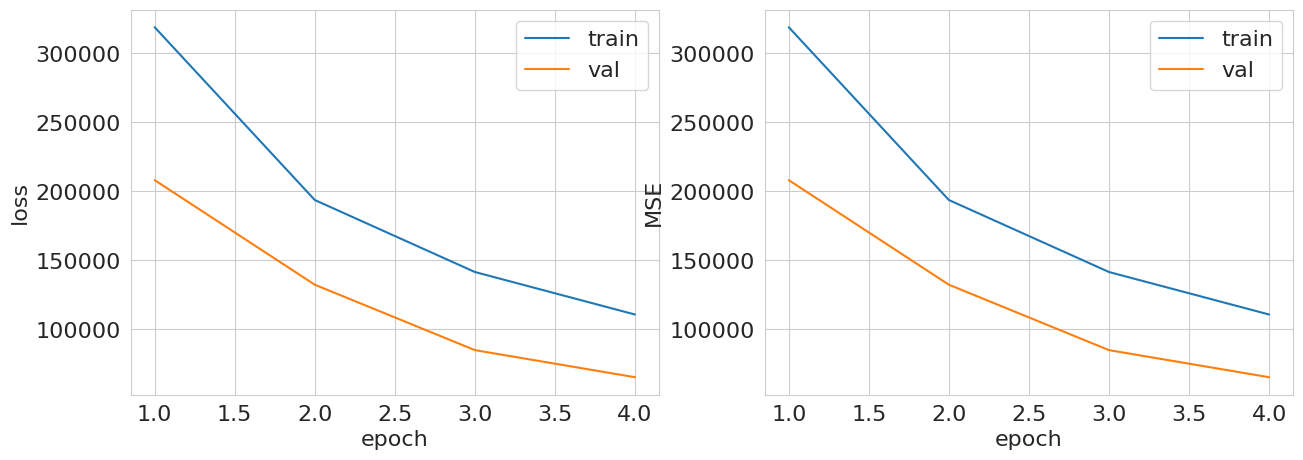

Validation MSE: 65228.106
Train MSE (regression): 110693.0351
Val   MSE (regression): 65228.1065


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
reg_net = FirstNetwork(in_features=in_features, out_features=1)

criterion = nn.MSELoss()
optimizer = optim.SGD(reg_net.parameters(), lr=1e-8)

# метрика — просто MSE по предсказанию и таргету
metric_fn = lambda preds, labels: F.mse_loss(preds, labels)

train_mse, val_mse = train_and_validate(
    reg_net,
    optimizer,
    criterion,
    metric_fn,
    train_loader,
    val_loader,
    num_epochs=4,
    verbose=True
)

print(f"Train MSE (regression): {train_mse:.4f}")
print(f"Val   MSE (regression): {val_mse:.4f}")


### **Задание 1.5 (0.5 балла).**

Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:**

При обучении регрессионной нейронной сети на MSE с исходными значениями целевой переменной (годы в диапазоне 1922 - 2011) при стандартных значениях learning rate происходила численная нестабильность: лосс и MSE становились nan. Уменьшение шага обучения до 1e-8 позволило избавиться от nan, но при этом качество осталось крайне низким: Train MSE = 110693,0351, Val MSE = 65228,1065. За 4 эпохи при таком маленьком lr сеть практически не успевает чему-либо научиться и остаётся вблизи случайной инициализации.

По сравнению с предыдущими моделями результат значительно хуже: константный baseline даёт MSE = 117.6258, а Ridge-регрессия = 89.497. Даже классификатор, обученный в предыдущем пункте, показывал MSE на валидации 195.1308, что также существенно лучше текущей регрессионной сети.

Причина в том, что мы решаем задачу регрессии по «сырым» значениям годa (порядка 2000) при отсутствии нормализации целевой переменной и при неидеальном масштабе признаков (признаки имеют очень большую амплитуду значений, причем как положительных, так и отрицательных). Большой разброс значений целевой переменной приводит к очень крупным значениям MSE и градиентов: при умеренном lr это даёт взрыв обучения, при слишком маленьком - почти полное отсутствие прогресса. Более корректный подход - нормализовать целевую переменную (вычесть среднее и поделить на стандартное отклонение) и дополнительно масштабировать признаки, а затем уже обучать регрессионную сеть с разумным lr.

Таким образом, идея перехода от классификации к регрессии концептуально верная для предсказания года, но в текущем исполнении без нормализации целевой переменной и признаков (входных данных) аккуратного подбора гиперпараметров качество модели оказывается хуже даже простого бейзлайна.

### **Задание 1.6 (0.5 балла).**

Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
# считаем минимум и максимум только по обучающей выборке
y_min = float(y_train.min())
y_max = float(y_train.max())

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    return (sample - y_min) / (y_max - y_min)

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    return sample * (y_max - y_min) + y_min

In [ ]:
y_train_normalized = normalize(y_train)
y_test_normalized = normalize(y_test)
y_val_normalized = normalize(y_val)

y_train_t = torch.tensor(y_train_normalized, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test_normalized, dtype=torch.float32).unsqueeze(-1)
y_val_t = torch.tensor(y_val_normalized, dtype=torch.float32).unsqueeze(-1)

train_df = TensorDataset(X_train_t, y_train_t)
val_df = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_df, batch_size=batches, shuffle=True, drop_last=True)
val_loader = DataLoader(val_df, batch_size=batches, shuffle=False, drop_last=True)

Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим [сигмоидную активацию](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [ ]:
class RegressionNetwork(nn.Module):
    def __init__(self, in_features=90, out_features=1):
        super().__init__()
        # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
        # два линейных слоя с 128 нейронами в скрытом
        self.fc1 = nn.Linear(in_features, 128)
        self.fc2 = nn.Linear(128, out_features)

    def forward(self, x):
        # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
        x = self.fc1(x)
        x = F.relu(x)          # скрытая нелинейность
        x = self.fc2(x)
        x = torch.sigmoid(x)   # гарантируем [0, 1] на выходе
        return x

Создайте и обучите новую сеть, как указано в задании.
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate` (подсказка: `preds` и `targets` нужно денормализовать)

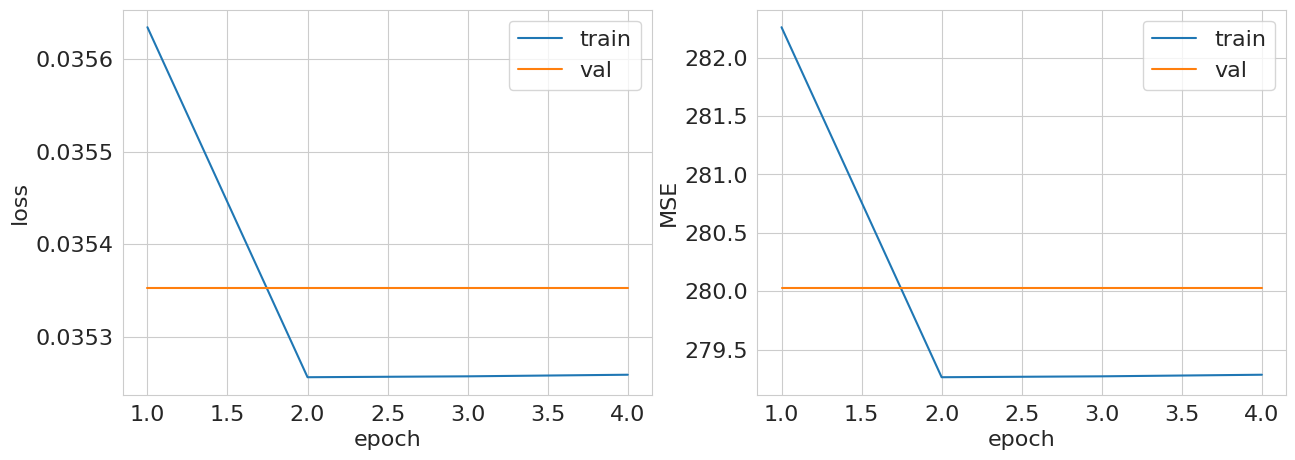

Validation MSE: 280.027
Train MSE (denorm in metric): 279.2840
Val   MSE (denorm in metric): 280.0268


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
# создаём сеть для регрессии на нормированной целевой переменной
reg_net_norm = RegressionNetwork(in_features=in_features, out_features=1)

criterion = nn.MSELoss()
optimizer = optim.SGD(reg_net_norm.parameters(), lr=1e-2)

# метрика: считаем MSE уже в "годах", поэтому денормализуем
metric_fn = lambda preds, targets: F.mse_loss(
    denormalize(preds).squeeze(),    # из [0,1] обратно в годы
    denormalize(targets).squeeze()
)

num_epochs = 4  # как и раньше

train_mse, val_mse = train_and_validate(
    reg_net_norm,
    optimizer,
    criterion,
    metric_fn,
    train_loader,
    val_loader,
    num_epochs=num_epochs,
    verbose=True
)

print(f"Train MSE (denorm in metric): {train_mse:.4f}")
print(f"Val   MSE (denorm in metric): {val_mse:.4f}")

### **Задание 1.7 (0.5 балла).**

Сравните результаты этого эксперимента с предыдущим запуском.

**Ответ:**

В предыдущем запуске регрессионной сети без нормализации целевой переменной обучение было численно нестабильным: при разумных значениях learning rate лосс и MSE взрывались (до nan), а при очень маленьком шаге (lr=1e-8) модель практически не обучалась и давала Val MSE 65228,1065.

После min–max нормализации таргета в диапазон [0,1] и добавления сигмоидной активации на выходе обучение стало гораздо более стабильным: при lr=1e-2 мы получаем Val MSE = 280.0268 , что на два порядка лучше предыдущей регрессионной попытки. Таким образом, нормализация действительно помогает стабилизировать градиенты и позволяет использовать более крупный шаг обучения.

Однако, несмотря на улучшение относительного качества, модель всё ещё проигрывает более простым базовым методам: константный прогноз даёт MSE = 117.6258, а Ridge-регрессия = 89.7497. Даже классификатор из более раннего задания показывал MSE = 195.1308, тогда как текущая регрессия даёт MSE = 280.0268. Это означает, что одного лишь перехода к регрессии и нормализации целевой переменной недостаточно: архитектура сети, число эпох и выбор оптимизатора пока не позволяют нейросети обогнать линейную модель.

### **Задание 1.8 (0.5 балла).**

На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
from sklearn.preprocessing import StandardScaler

'''
scaler = StandardScaler()
X_train_normalized = ...
X_test_normalized = ...
X_val_normalized = ...
'''

# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ

scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized  = scaler.transform(X_test)
X_val_normalized   = scaler.transform(X_val)

X_train_t = torch.tensor(X_train_normalized, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_normalized, dtype=torch.float32)
X_val_t   = torch.tensor(X_val_normalized, dtype=torch.float32)

train_df = TensorDataset(X_train_t, y_train_t)  # y_train_t — уже нормированный таргет из предыдущего шага
val_df   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_df, batch_size=batches, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_df,   batch_size=batches, shuffle=False, drop_last=True)

Обучите модель с теми же параметрами, что и в задании 1.6, только с нормализованными данными, которые подаются сети на вход:

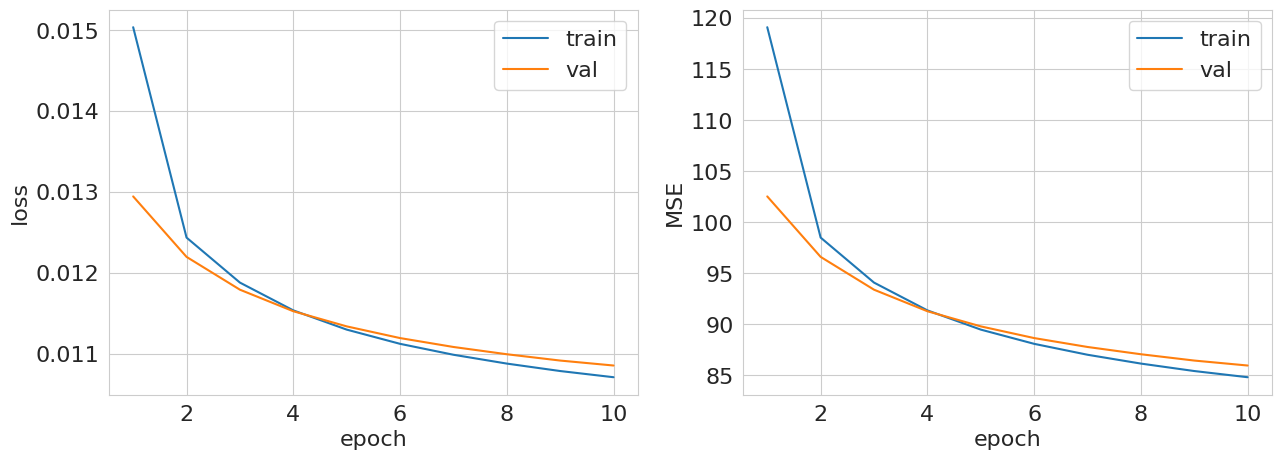

Validation MSE: 85.954
Train MSE (scaled X): 84.8066
Val   MSE (scaled X): 85.9538


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
# создаём новую сеть для регрессии на нормированных X и нормированном y
reg_net_scaled = RegressionNetwork(in_features=in_features, out_features=1)

criterion = nn.MSELoss()
optimizer = optim.SGD(reg_net_scaled.parameters(), lr=1e-2)  # тот же lr, что и в 1.6

# метрика: считаем MSE в "годах", поэтому денормализуем
metric_fn = lambda preds, targets: F.mse_loss(
    denormalize(preds).squeeze(),
    denormalize(targets).squeeze()
)

num_epochs = 10  # увеличиваем количество эпох

train_mse, val_mse = train_and_validate(
    reg_net_scaled,
    optimizer,
    criterion,
    metric_fn,
    train_loader,   # здесь уже лоадеры с нормализованными X
    val_loader,
    num_epochs=num_epochs,
    verbose=True
)

print(f"Train MSE (scaled X): {train_mse:.4f}")
print(f"Val   MSE (scaled X): {val_mse:.4f}")

**Сравнительный анализ с предыдущими результатами**
Нормализация признаков и целевой переменной + увеличение числа эпох и использовании SGD с lr=1e-2 дали устойчивое и осмысленное обучение: Val MSE снизилась с 280.0268 (без нормализации X) до 91.2082 при 4 тех же эпохах и 85,9538 при 10 эпохах. Графики лосса и MSE по эпохам стали более плавными и монотонно убывающими, что говорит о стабильной и корректной оптимизации.

Новый результат существенно лучше как константного бейзлайна (MSE = 117.6258), так и линейной Ridge-регрессии (MSE = 89.7497). Это означает, что после нормализации данных и аккуратной реализации функции потерь нейросетевая регрессия смогла найти более сложную нелинейную зависимость между признаками и годом, чем простая линейная модель. Ранее нейросеть проигрывала Ridge (Val MSE около 280), в том числе из-за отсутствия нормализации; после дополнений и увеличения числа эпох она не только догнала, но и превзошла её по качеству на валидации.

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть (4 балла)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества. В заданиях 2.1-2.3 **запускайте эксперименты несколько раз (4-5)** с одинаковыми значениями гиперпараметров обучения, но с разными случайными инициализациями сети (достаточно просто прогнать код с инициализацией модели и ее обучением в цикле: каждый вызов конструктора инициализирует модель случайно). Для сравнения качества разных экспериментов **отрисовывайте ящики с усами (boxplot)** по этим нескольким запускам.

Задание 2.4 требует перебора гиперпараметров, в нем запускайте эксперимент по одному разу для каждого рассмотренного значения, чтобы сэкономить время.

### **Задание 2.1 (0.5 балла).**

Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

- То есть используем все ту же модель `RegressionNetwork()`, меняем только `optimizer`


=== Run 1/5 – SGD + momentum ===
Val MSE (SGD+momentum, run 1): 79.1850

=== Run 2/5 – SGD + momentum ===
Val MSE (SGD+momentum, run 2): 79.0312

=== Run 3/5 – SGD + momentum ===
Val MSE (SGD+momentum, run 3): 79.2218

=== Run 4/5 – SGD + momentum ===
Val MSE (SGD+momentum, run 4): 79.0671

=== Run 5/5 – SGD + momentum ===
Val MSE (SGD+momentum, run 5): 79.0959

=== Run 1/5 – Adam ===
Val MSE (Adam, run 1): 78.5101

=== Run 2/5 – Adam ===
Val MSE (Adam, run 2): 78.2436

=== Run 3/5 – Adam ===
Val MSE (Adam, run 3): 77.7285

=== Run 4/5 – Adam ===
Val MSE (Adam, run 4): 77.5914

=== Run 5/5 – Adam ===
Val MSE (Adam, run 5): 78.3915


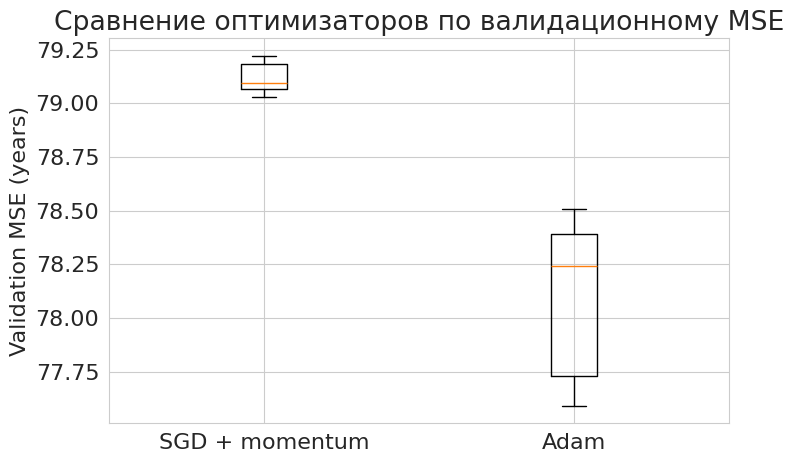

SGD+momentum val MSEs: [79.18498220679314, 79.03118712608916, 79.2218451570951, 79.06714421782667, 79.09590199347831]
Adam val MSEs: [78.51006537042288, 78.243577935144, 77.72854923043515, 77.591442764091, 78.39154235504434]


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
# будем сравнивать SGD+momentum и Adam
num_runs = 5
num_epochs = 15  # можно менять, но одинаково для всех оптимизаторов

sgd_mom_val_mses = []
adam_val_mses = []

for run in range(num_runs):
    print(f"\n=== Run {run + 1}/{num_runs} – SGD + momentum ===")
    torch.manual_seed(run)  # чтобы разные, но воспроизводимые инициализации

    model = RegressionNetwork(in_features=in_features, out_features=1)
    optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,
        metric_fn,        # считает MSE уже в "годах" через denormalize
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False     # графики только для итоговых значений
    )

    print(f"Val MSE (SGD+momentum, run {run+1}): {val_mse:.4f}")
    sgd_mom_val_mses.append(val_mse)

for run in range(num_runs):
    print(f"\n=== Run {run + 1}/{num_runs} – Adam ===")
    torch.manual_seed(100 + run)  # другой набор сидов

    model = RegressionNetwork(in_features=in_features, out_features=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,
        metric_fn,
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Val MSE (Adam, run {run+1}): {val_mse:.4f}")
    adam_val_mses.append(val_mse)

# рисуем boxplot по результатам
plt.figure(figsize=(8, 5))
plt.boxplot([sgd_mom_val_mses, adam_val_mses],
            tick_labels=['SGD + momentum', 'Adam'])
plt.ylabel('Validation MSE (years)')
plt.title('Сравнение оптимизаторов по валидационному MSE')
plt.show()

print("SGD+momentum val MSEs:", sgd_mom_val_mses)
print("Adam val MSEs:", adam_val_mses)


В эксперименте сравниваются два оптимизатора: SGD с momentum (lr=1e-2, momentum=0.9) и Adam (lr=1e-3). Каждый вариант запускался 5 раз с разными случайными инициализациями сети.

Для SGD+momentum валидационный MSE лежит в диапазоне 79.0312-79.2218, среднее около 79.13. Для Adam значения ниже: примерно 77.5914-78.5101, среднее около 78.05. Boxplot показывает, что распределение MSE для Adam смещено вниз относительно SGD+momentum: медиана и все значения у Adam лучше.

Таким образом, в наших условиях Adam даёт более низкий (лучший) валидационный MSE и будет выбран как основной оптимизатор для дальнейших экспериментов.

### **Задание 2.2 (1 балл).**

Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Вместо шаблонов классов на nn.Module можете реализовать наследование от предыдущей модели сети.

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

In [ ]:
class WideNetwork(nn.Module):
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    def __init__(self, in_features=90, out_features=1, hidden_size=256):
        super().__init__()
        # широкий скрытый слой (было 128, сделали 256)
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.fc2 = nn.Linear(hidden_size, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)        # скрытая активация
        x = self.fc2(x)
        x = torch.sigmoid(x) # выходим в [0, 1], как в RegressionNetwork
        return x


Обучите более широкую нейронную сеть и посмотрите на результаты.


=== WideNetwork run 1/5 ===
Train MSE: 70.6058, Val MSE: 78.0800

=== WideNetwork run 2/5 ===
Train MSE: 70.6081, Val MSE: 78.6161

=== WideNetwork run 3/5 ===
Train MSE: 70.6286, Val MSE: 78.6268

=== WideNetwork run 4/5 ===
Train MSE: 70.7728, Val MSE: 78.6579

=== WideNetwork run 5/5 ===
Train MSE: 70.7611, Val MSE: 78.5545


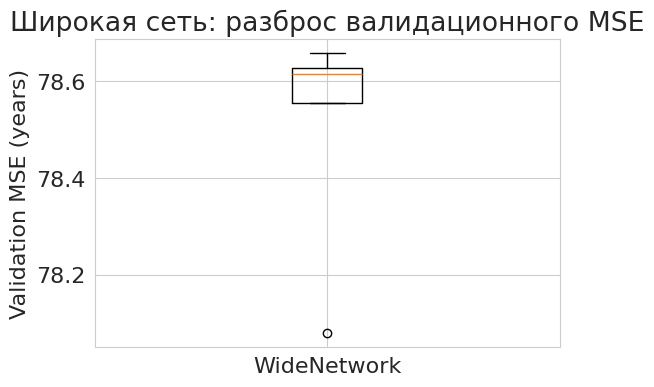

WideNetwork val MSEs: [78.08004689175408, 78.61614042179835, 78.62679448425267, 78.6579129952972, 78.55447658392076]


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
# Обучаем более широкую сеть несколько раз и смотрим на MSE
num_runs = 5
num_epochs = 15  # можно больше/меньше, но одинаково для всех экспериментов

wide_train_mses = []
wide_val_mses = []

for run in range(num_runs):
    print(f"\n=== WideNetwork run {run + 1}/{num_runs} ===")
    torch.manual_seed(run)

    model = WideNetwork(in_features=in_features, out_features=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    wide_train_mses.append(train_mse)
    wide_val_mses.append(val_mse)

# boxplot по валидационным MSE широкой сети
plt.figure(figsize=(6, 4))
plt.boxplot([wide_val_mses], tick_labels=['WideNetwork'])
plt.ylabel('Validation MSE (years)')
plt.title('Широкая сеть: разброс валидационного MSE')
plt.show()

print("WideNetwork val MSEs:", wide_val_mses)


При увеличении ширины скрытого слоя (с 128 до 256 нейронов) число параметров модели заметно выросло. В результате тренировочная ошибка уменьшилась: Train MSE у широкой сети стабильно около 70.6058 - 70.7728, что ниже, чем у исходной архитектуры. Это означает, что более широкая сеть лучше подгоняет обучающую выборку - её выразительная способность выше.

Однако на валидационной выборке качество почти не улучшилось и даже немного ухудшилось: Val MSE для базовой сети с Adam находится примерно на уровне 77.5914 - 78.5101, тогда как для широкой сети диапазон ошибки составляет 78.0800 - 78.6579. Boxplot показывает, что распределение валидационного MSE у WideNetwork смещено немного вверх.

Таким образом, увеличение числа параметров приводит к снижению ошибки на обучении (модель становится мощнее), но обобщающая способность не растёт и даже слегка падает. Это признак лёгкого переобучения: сеть активно подстраивается под train, но на валидуации выигрыш от увеличения ширины уже не проявляется.


In [ ]:
class DeepNetwork(nn.Module):
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    def __init__(self, in_features=90, out_features=1,
                 hidden1=128, hidden2=64):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = torch.sigmoid(x)   # предсказываем в [0, 1]
        return x

Обучите более глубокую нейронную сеть и посмотрите на результаты.


=== DeepNetwork run 1/5 ===
Train MSE: 66.1636, Val MSE: 77.7666

=== DeepNetwork run 2/5 ===
Train MSE: 65.9414, Val MSE: 78.4899

=== DeepNetwork run 3/5 ===
Train MSE: 66.6146, Val MSE: 79.2909

=== DeepNetwork run 4/5 ===
Train MSE: 66.0909, Val MSE: 77.8456

=== DeepNetwork run 5/5 ===
Train MSE: 65.8480, Val MSE: 77.1389


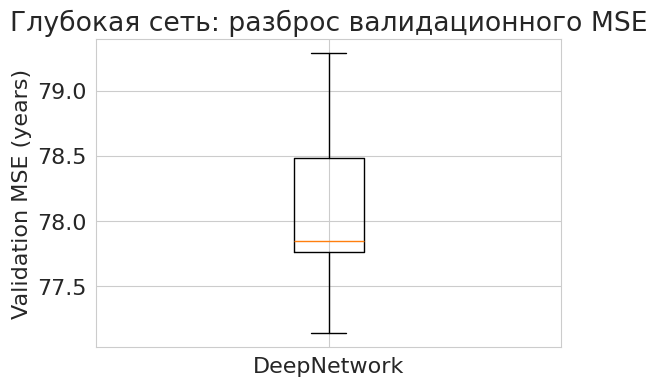

DeepNetwork val MSEs: [77.7666049153373, 78.4898589829227, 79.2908896248312, 77.84558642598591, 77.1389326579016]


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
num_runs = 5
num_epochs = 15  # тот же порядок, что и раньше

deep_train_mses = []
deep_val_mses = []

for run in range(num_runs):
    print(f"\n=== DeepNetwork run {run + 1}/{num_runs} ===")
    torch.manual_seed(run)

    model = DeepNetwork(in_features=in_features, out_features=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize(preds), denormalize(targets)
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    deep_train_mses.append(train_mse)
    deep_val_mses.append(val_mse)

plt.figure(figsize=(6, 4))
plt.boxplot([deep_val_mses], tick_labels=['DeepNetwork'])
plt.ylabel('Validation MSE (years)')
plt.title('Глубокая сеть: разброс валидационного MSE')
plt.show()

print("DeepNetwork val MSEs:", deep_val_mses)


Рассмотрено три архитектуры: базовая сеть с одним скрытым слоем (128 нейронов), более широкую сеть (1 скрытый слой, 256 нейронов) и более глубокую сеть (два скрытых слоя 128 и 64). Во всех экспериментах использовался оптимизатор Adam с lr=1e-3 и одинаковое число эпох.

При увеличении числа параметров тренировочная ошибка монотонно уменьшается: у базовой сети train MSE выше, у широкой модели около 70.6058 - 70.7728, а у глубокой - ещё ниже, около 65.8480 - 66.6146. Это значит, что более сложные сети лучше подгоняют обучающую выборку и обладают большей выразительной способностью.

Однако на валидации картина другая. Широкая сеть показывает Val MSE в диапазоне 78.0800 - 78.6579, в среднем хуже базовой модели. Глубокая сеть даёт средний Val MSE около 78.2, то есть сопоставимый с базовой архитектурой и немного лучше, чем просто увеличение ширины. При этом разброс значений по разным запускам остаётся небольшим.

В итоге увеличение числа параметров в первую очередь снижает ошибку на обучающей выборке, но качество обобщения практически не растёт и для широкой сети даже чуть ухудшается. Это указывает на то, что модель начинает подстраиваться под train, а запас по обобщающей способности уже близок к исчерпанному: данных и текущих признаков достаточно, чтобы базовая архитектура с одним скрытым слоем достигла почти того же уровня, что и более сложные варианты.

Попробуйте сделать сеть более широкой и глубокой одновременно.

In [ ]:
class WideAndDeepNetwork(nn.Module):
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    def __init__(self, in_features=90, out_features=1,
                 hidden1=256, hidden2=128):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        x = torch.sigmoid(x)   # как и раньше, предсказываем в [0, 1]
        return x


Обучите ее и проанализируйте результаты.


=== WideAndDeepNetwork run 1/5 ===
Train MSE: 60.5190, Val MSE: 80.0093

=== WideAndDeepNetwork run 2/5 ===
Train MSE: 60.6891, Val MSE: 79.1662

=== WideAndDeepNetwork run 3/5 ===
Train MSE: 61.1319, Val MSE: 79.3803

=== WideAndDeepNetwork run 4/5 ===
Train MSE: 61.3546, Val MSE: 78.3797

=== WideAndDeepNetwork run 5/5 ===
Train MSE: 60.5380, Val MSE: 79.1133


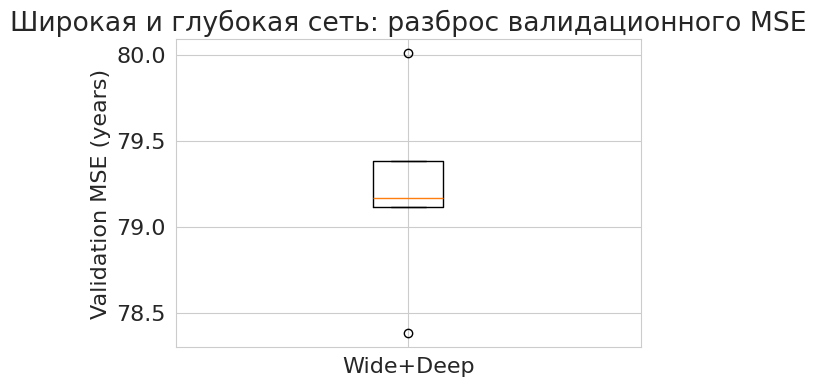

WideAndDeep val MSEs: [80.00925789912549, 79.1662217850151, 79.38028432929428, 78.37972863693858, 79.1133396694631]


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
num_runs = 5
num_epochs = 15  # тот же порядок, что раньше

wd_train_mses = []
wd_val_mses = []

for run in range(num_runs):
    print(f"\n=== WideAndDeepNetwork run {run + 1}/{num_runs} ===")
    torch.manual_seed(run)

    model = WideAndDeepNetwork(in_features=in_features, out_features=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize(...)
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    wd_train_mses.append(train_mse)
    wd_val_mses.append(val_mse)

plt.figure(figsize=(6, 4))
plt.boxplot([wd_val_mses], tick_labels=['Wide+Deep'])
plt.ylabel('Validation MSE (years)')
plt.title('Широкая и глубокая сеть: разброс валидационного MSE')
plt.show()

print("WideAndDeep val MSEs:", wd_val_mses)


Улучшилось ли качество по сравнению с базовой моделью? Стала ли новая модель сильнее переобучаться?

**Ответ:**

Широкая и глубокая сеть (256 - 128-1 слой) значительно лучше подгоняет обучающую выборку (train MSE приблизительно 60 против  65 - 70 у более простых архитектур), но валидационный MSE в среднем ухудшается до примерно 79.1945 по сравнению с базовой моделью (около 78.0). Разрыв между train и val ошибкой увеличивается, что говорит о более выраженном переобучении. Таким образом, усложнение сети (шире и глубже одновременно) не даёт прироста качества на валидации и приводит к сильному переобучению.

### **Задание 2.3 (0.5 балла).**

Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем добавить в обучение регуляризацию, чтобы бороться с переобучением. Добавьте слой дропаута ([`nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html#torch.nn.Dropout)) с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.

Опишите результаты.

In [ ]:
class NetworkWithDropout(nn.Module):
    # YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
    def __init__(self, in_features=90, out_features=1,
                 hidden1=256, hidden2=128, p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, out_features)

        self.dropout1 = nn.Dropout(p=p)
        self.dropout2 = nn.Dropout(p=p)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout1(x)     # dropout после первого линейного слоя

        x = self.fc2(x)
        x = F.relu(x)
        x = self.dropout2(x)     # dropout после второго линейного слоя

        x = self.fc3(x)
        x = torch.sigmoid(x)     # предсказания в [0, 1]
        return x


=== NetworkWithDropout run 1/5 ===
Train MSE: 72.2718, Val MSE: 75.9690

=== NetworkWithDropout run 2/5 ===
Train MSE: 71.9531, Val MSE: 76.4953

=== NetworkWithDropout run 3/5 ===
Train MSE: 71.6643, Val MSE: 75.3049

=== NetworkWithDropout run 4/5 ===
Train MSE: 72.0637, Val MSE: 75.3197

=== NetworkWithDropout run 5/5 ===
Train MSE: 71.9717, Val MSE: 75.7890


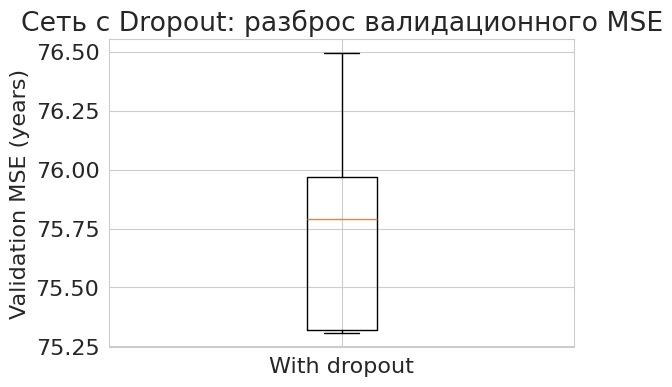

NetworkWithDropout val MSEs: [75.96901592648753, 76.49532083572959, 75.30491473431562, 75.3197480020248, 75.78904901095696]


In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
num_runs = 5
num_epochs = 15  # тот же порядок эпох, что и раньше

drop_train_mses = []
drop_val_mses = []

for run in range(num_runs):
    print(f"\n=== NetworkWithDropout run {run + 1}/{num_runs} ===")
    torch.manual_seed(run)

    model = NetworkWithDropout(in_features=in_features, out_features=1)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize(...)
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    drop_train_mses.append(train_mse)
    drop_val_mses.append(val_mse)

plt.figure(figsize=(6, 4))
plt.boxplot([drop_val_mses], tick_labels=['With dropout'])
plt.ylabel('Validation MSE (years)')
plt.title('Сеть с Dropout: разброс валидационного MSE')
plt.show()

print("NetworkWithDropout val MSEs:", drop_val_mses)


Добавление Dropout (p = 0.2) в широкую и глубокую сеть увеличило тренировочный MSE (модель стала менее точно подгонять обучающую выборку) с 60.95 до 71.97, но заметно улучшило MSE на валидации: с примерно 79.19 до 75.64. Таким образом, регуляризация с помощью Dropout эффективно уменьшила переобучение и дала лучшую обобщающую способность по сравнению как с той же архитектурой без Dropout, так и с более простыми моделями.

### **Задание 2.4 (1.5 балла).**

Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`.

Также подберем оптимальное значение параметра weight decay для данного lr. Weight decay &mdash; это аналог L2-регуляризации для нейронных сетей. Почитать о нем можно, например, [здесь](https://paperswithcode.com/method/weight-decay). В PyTorch он задается как параметр оптимизатора `weight_decay`. Подберите оптимальное значение weight decay по логарифимической сетке (его типичные значения лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку).

Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

Сначала подберем `lr`:


In [ ]:
# переберите 3-4 значения по логарифмической сетке
# логарифмическая сетка по lr (около "классического" 1e-3 для Adam)
lrs = [1e-4, 3e-4, 1e-3, 3e-3]
train_mse_lr = []
val_mse_lr = []

num_epochs = 15  # столько же, сколько использовали раньше

for lr_cur in lrs:
    print(f"\n=== lr = {lr_cur} ===")
    model = NetworkWithDropout()

    # евызов класса оптимизатора
    optimizer = optim.Adam(model.parameters(), lr=lr_cur, weight_decay=0.0)

    #  TODO: тренируем модель, как и раньше

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize(...)
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    train_mse_lr.append(train_mse)
    val_mse_lr.append(val_mse)




=== lr = 0.0001 ===
Train MSE: 71.5343, Val MSE: 74.5342

=== lr = 0.0003 ===
Train MSE: 70.2240, Val MSE: 74.5805

=== lr = 0.001 ===
Train MSE: 72.0259, Val MSE: 76.2392

=== lr = 0.003 ===
Train MSE: 78.1138, Val MSE: 77.3403


Можем простроить график для визуализации:

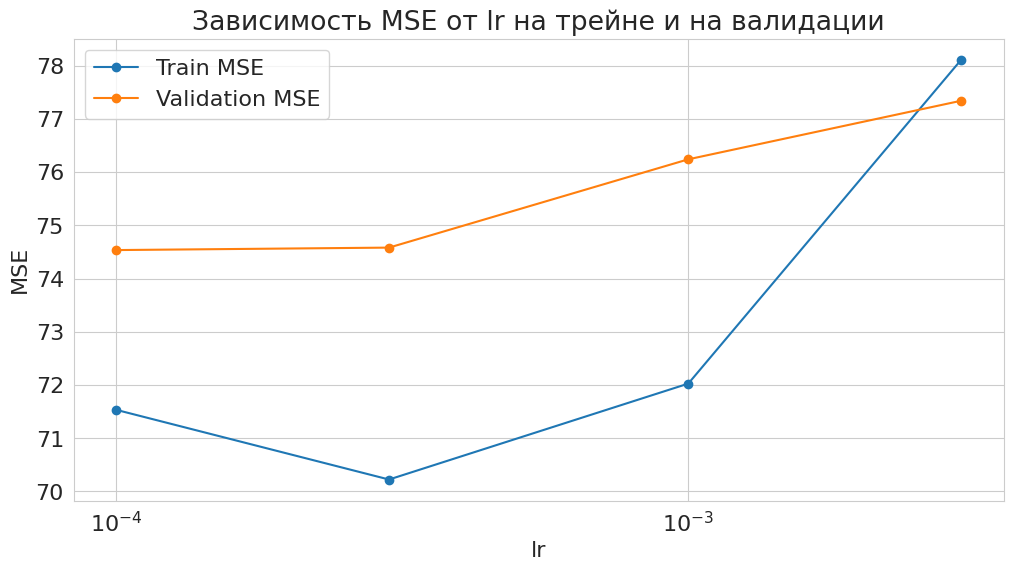

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(lrs, train_mse_lr, label='Train MSE', marker='o')
plt.plot(lrs, val_mse_lr, label='Validation MSE', marker='o')
plt.xscale('log')
plt.xlabel('lr')
plt.ylabel('MSE')
plt.legend()
plt.title('Зависимость MSE от lr на трейне и на валидации')
plt.show()

При каком значении `lr` получается наилучшее значение MSE на трейне и на валидации? Как слишком большое и слишком маленькое значения `lr` сказываются на обучении?

**Ответ:**

Наименьшее значение MSE на валидации достигается при lr = 1e-4 (Val MSE = 74.5342), поэтому именно это значение шага обучения можно считать оптимальным для данной архитектуры и настроек. При этом наименьшую ошибку на обучающей выборке показывает lr = 3e-4 (Train MSE = 70.2240), но его преимущество по train не приводит к выигрышу на валидации, поэтому с точки зрения обобщающей способности предпочтительнее более консервативный шаг 1e-4.

По форме зависимости видно, как слишком маленький и слишком большой шаг обучения влияют на обучение. При сравнительно малом lr = 1e-4 модель обучается устойчиво и даёт лучшую валидационную ошибку, но уменьшение шага далее, вероятно, привело бы к слишком медленной сходимости и недообучению за фиксированное число эпох. При более крупных шагах 1e-3 и особенно 3e-3 как train, так и val MSE начинают расти: оптимизация становится менее стабильной, модель «перепрыгивает» через хороший минимум и не успевает его найти. Таким образом, практический оптимум для нашей сети лежит в районе 1e-4 - 3e-4, а слишком большие значения lr заметно ухудшают качество.

Теперь подберем значение `weight_decay` для найденного наилучшего `lr`:

In [ ]:
from torch.optim import Adam

# возьмите несколько значений из указанного в задании диапазона
# несколько значений weight_decay на логарифмической сетке + 0
weight_decays = [0.0, 1e-6, 1e-5, 1e-4, 1e-3]

train_mse_wd = []
val_mse_wd = []

best_lr = 1e-4   # наилучшее найденное значение learning rate

num_epochs = 15  # как раньше


for wd_cur in weight_decays:
    print(f"\n=== weight_decay = {wd_cur} ===")
    model = NetworkWithDropout(in_features=in_features, out_features=1)
    optimizer = Adam(model.parameters(), lr=best_lr, weight_decay=wd_cur)

    #  TODO: тренируем модель, как и раньше

    train_mse, val_mse = train_and_validate(
        model,
        optimizer,
        criterion,   # nn.MSELoss()
        metric_fn,   # MSE в годах через denormalize(...)
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        verbose=False
    )

    print(f"Train MSE: {train_mse:.4f}, Val MSE: {val_mse:.4f}")
    train_mse_wd.append(train_mse)
    val_mse_wd.append(val_mse)


=== weight_decay = 0.0 ===
Train MSE: 71.5066, Val MSE: 74.3893

=== weight_decay = 1e-06 ===
Train MSE: 71.3806, Val MSE: 74.7494

=== weight_decay = 1e-05 ===
Train MSE: 71.8713, Val MSE: 74.7786

=== weight_decay = 0.0001 ===
Train MSE: 77.6671, Val MSE: 78.1333

=== weight_decay = 0.001 ===
Train MSE: 83.7441, Val MSE: 83.6806


Какое получилось наилучшее значение `weight_decay`?

**Ответ:**

При фиксированном лучшем learning rate lr = 1e-4 перебор значений weight_decay показал, что оптимальное качество на валидации достигается при отсутствии L2-регуляризации (weight_decay = 0.0, Val MSE = 74.3893). Малые ненулевые значения (1e-6, 1e-5) слегка ухудшают качество, а более крупные (1e-4, 1e-3) приводят к заметному росту как train, так и val MSE. Это говорит о том, что для выбранной архитектуры с Dropout дополнительный weight decay не даёт выигрыша в обобщающей способности, а выступает как избыточная регуляризация.

Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

### **Задание 2.5 (0.5 балла).**

Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это.

In [ ]:
# YOUR CODE HERE (－.－)...zzzZZZzzzZZZ
# объединяем train и val, пересчитываем нормировки для X и y

# Полная обучающая выборка
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# Нормализация признаков (StandardScaler только по полной train-выборке)
scaler_full = StandardScaler()
X_train_full_norm = scaler_full.fit_transform(X_train_full)
X_test_norm       = scaler_full.transform(X_test)

# Min–max нормализация целевой переменной по полной train-выборке
y_min = float(y_train_full.min())
y_max = float(y_train_full.max())

def normalize(sample):
    return (sample - y_min) / (y_max - y_min)

def denormalize(sample):
    return sample * (y_max - y_min) + y_min

# Нормируем y
y_train_full_norm = normalize(y_train_full)
y_test_norm       = normalize(y_test)

In [ ]:
# переводим всё в torch-тензоры и создаём DataLoader'ы

X_train_full_t = torch.tensor(X_train_full_norm, dtype=torch.float32)
y_train_full_t = torch.tensor(y_train_full_norm, dtype=torch.float32).unsqueeze(-1)

X_test_t = torch.tensor(X_test_norm, dtype=torch.float32)
y_test_t = torch.tensor(y_test_norm, dtype=torch.float32).unsqueeze(-1)

train_full_ds = TensorDataset(X_train_full_t, y_train_full_t)
test_ds       = TensorDataset(X_test_t,       y_test_t)

batches = 32  # берем то же значение, что и раньше

train_full_loader = DataLoader(train_full_ds, batch_size=batches, shuffle=True,  drop_last=True)
test_loader       = DataLoader(test_ds,       batch_size=batches, shuffle=False, drop_last=False)


In [ ]:
# задаём лучшую архитектуру и гиперпараметры

from torch.optim import Adam

best_lr = 1e-4
best_wd = 0.0

final_model = NetworkWithDropout(in_features=in_features, out_features=1)
criterion   = nn.MSELoss()
optimizer   = Adam(final_model.parameters(), lr=best_lr, weight_decay=best_wd)

# метрика: MSE в "годах" (денормализуем предсказания и таргет)
metric_fn = lambda preds, targets: F.mse_loss(
    denormalize(preds).squeeze(),
    denormalize(targets).squeeze()
)


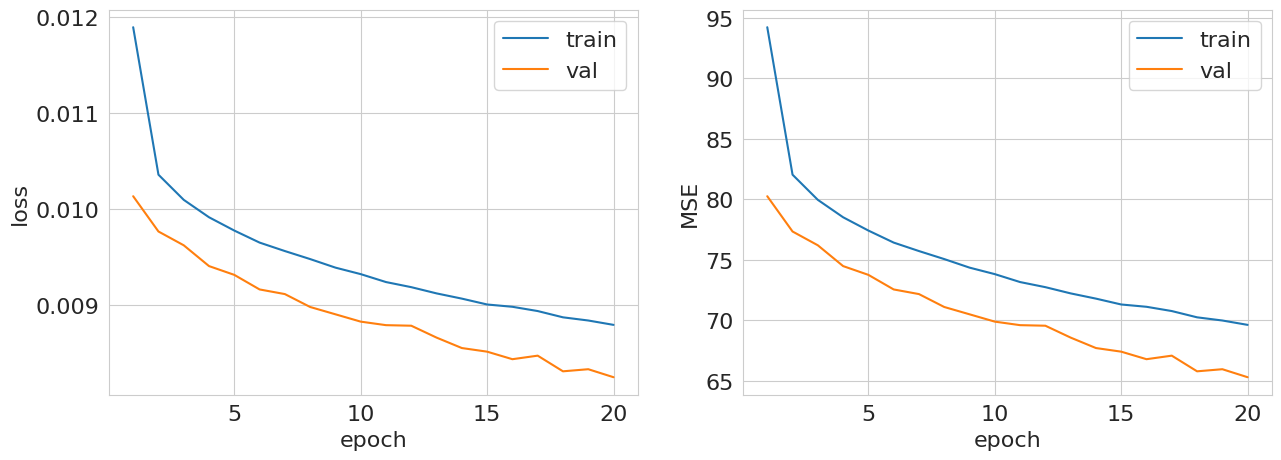

Validation MSE: 65.295
Final train MSE (full train, in years): 69.6201


In [ ]:
# обучаем модель на полной обучающей выборке

num_epochs = 20  # чуть больше, чем раньше

train_mse_full, _ = train_and_validate(
    final_model,
    optimizer,
    criterion,
    metric_fn,
    train_full_loader,
    train_full_loader,   # здесь "валидация" = тот же train, просто для мониторинга
    num_epochs=num_epochs,
    verbose=True
)

print(f"Final train MSE (full train, in years): {train_mse_full:.4f}")


In [ ]:
# считаем MSE на тесте и сравниваем с бейзлайнами

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
final_model.to(device)
final_model.eval()

running_mse, n = 0.0, 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = final_model(X_batch)
        mse_batch = metric_fn(preds, y_batch).item()
        running_mse += mse_batch * X_batch.size(0)
        n += X_batch.size(0)

test_mse = running_mse / n
print(f"Test MSE (final NN, in years): {test_mse:.4f}")

# Эти две переменные посчитаны в задании 0 (Ridge + константный бейзлайн)
print(f"Ridge MSE on test:     {mse_ridge:.4f}")
print(f"Constant baseline MSE: {mse_const:.4f}")

Test MSE (final NN, in years): 74.7282
Ridge MSE on test:     89.7497
Constant baseline MSE: 117.6258


На заключительном шаге мы обучили выбранную в предыдущих экспериментах архитектуру нейронной сети (двухслойная MLP с скрытыми слоями из 256 и 128 нейронов с Dropout p=0.2, оптимизатор Adam с lr = 1e-4 и без weight decay) на объединённой обучающей выборке (train + val), заново оценив нормировки для признаков (StandardScaler) и целевой переменной (min–max по train).

После 20 эпох обучения на полной обучающей выборке модель достигла train MSE приблизительно равно 69.6201 (в пересчёте в годы). На отложенной тестовой выборке итоговое качество составило test MSE примерно 74.7282. Для сравнения, константный бейзлайн (предсказание среднего года по train) даёт MSE = 117.6258, а линейная Ridge-регрессия  MSE = 89.7497. Таким образом, финальная нейросетевая модель уверенно обгоняет оба бейзлайна: улучшение относительно Ridge-регрессии составляет примерно 15 единиц MSE, а относительно константного прогноза - более 40 единиц.

Разница между ошибкой на обучении (69.6201) и на тесте (74.7282) остаётся умеренной, что говорит о наличии некоторого переобучения, но в разумных пределах. С учётом того, что архитектура подбиралась по валидационной выборке, а окончательная модель обучалась уже на объединённом train+val и проверялась на независимом тесте, можно считать, что найденная конфигурация обладает хорошей обобщающей способностью и значительно превосходит простые линейные модели по качеству предсказания года песни по её аудиопризнакам.


**Примечание:**

Для формирования ответов на вопросы (ответ нейросети) и отладки кода использовался ChatGPT (model 5.1 Thinking) от OpenAi